# Avis Restau - Présentation des résultats

## ***** Détection des sujets d'insatisfaction *****

In [246]:
# import des librairies générales au notebook
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

# initialisations
warnings.filterwarnings('ignore')
pd.options.display.max_colwidth = 1000
plt.style.use('seaborn')


In [247]:

import json

""" 
extract a sample of sample_size lines from a json file
"""
def sample_file(filename,sample_size):
    lines = []
    with open(filename,'rb') as fl:
        for i, line in enumerate(fl):
            lines.append(json.loads(line))
            if i+1 >= sample_size:
                break
    fl.close()
    return pd.DataFrame(lines)

In [248]:
data_path = "./datas/"

In [249]:
sample_size = 50000
df_review = sample_file(data_path + "yelp_academic_dataset_review.json", sample_size)


In [250]:
df_business = pd.read_json(data_path + 'yelp_academic_dataset_business.json',lines=True)
df_review_business = df_review.merge(df_business[['business_id', 'categories']], on="business_id")
df_review_business_restau = df_review_business[df_review_business["categories"].str.contains("Restaurants")==True].reset_index()


### NLP Preprocessing

#### Test des fonctions:

In [251]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.corpus import wordnet as wn
from nltk.corpus import wordnet
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud, ImageColorGenerator
import contractions



In [252]:

# fonction de preprocessing

"""
remove special and numeric caracters from a text
"""
def remove_special_numeric_caracters(text):
    text = re.sub('[^a-zA-Z\s]','',text)
    return re.sub('\s+',' ',text)

"""
remove url from a text
"""
def remove_url(text):
    text = re.sub(r'http\S+', '', text)
    return re.sub('\s+',' ',text)

"""
remove uppercases from a text
"""
def lower(text):
    text_lower = str(text).lower()
    return text_lower

"""
remove stop words from a text
"""
def remove_stop_words(text):
    word_tokens = word_tokenize(text)
    filtered_text = [w for w in word_tokens if not w in stop_words]    
    return " ".join(filtered_text)

"""
expand contractions from a text
"""
def expand_contractions(text):    
    return contractions.fix(text)

"""
returns wordnet object from nltk tag
"""
def nltk_pos_tagger(nltk_tag):
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:          
        return None

"""
lemmatize a sentence
"""
def lemmatize_sentence(sentence):

    nltk_tagged = nltk.pos_tag(nltk.word_tokenize(sentence))  
    wordnet_tagged = map(lambda x: (x[0], nltk_pos_tagger(x[1])), nltk_tagged)
    lemmatized_sentence = []

    lemmatized_sentence = [lemmatizer.lemmatize(word, tag) if tag is not None else word for word, tag in wordnet_tagged ]
    return " ".join(lemmatized_sentence)

"""
lemmatize a sentence
faster version without wordnet pos tagging
"""
def lemmatize_sentence_fast(sentence):
    word_tokens = word_tokenize(sentence)
    filtered_text = [lemmatizer.lemmatize(item, 'v') for item in word_tokens] 
    filtered_text = [lemmatizer.lemmatize(item) for item in filtered_text] 
    return " ".join(filtered_text)



In [253]:
"""
print the preprocess test
"""
def print_test_preprocess(initial_text, cleaned_text):
    print('- initial text:')
    print(initial_text)
    print('\n')
    print('- cleaned text:')
    print(cleaned_text)
    

In [254]:
lemmatizer = WordNetLemmatizer()
stop_words = stopwords.words("english")


##### test remove url

In [255]:
initial_text = 'This is a text containing http://wwww.mysite.com an url'
cleaned_text = remove_url(initial_text)
print_test_preprocess(initial_text,cleaned_text)


- initial text:
This is a text containing http://wwww.mysite.com an url


- cleaned text:
This is a text containing an url


##### test expand contractions

In [256]:
initial_text = "This text has contractions. We're going to preprocess it. It doesn't keep contractions. Example : I don't like this restaurant"
cleaned_text = expand_contractions(initial_text)
print_test_preprocess(initial_text,cleaned_text)


- initial text:
This text has contractions. We're going to preprocess it. It doesn't keep contractions. Example : I don't like this restaurant


- cleaned text:
This text has contractions. we are going to preprocess it. It does not keep contractions. Example : I do not like this restaurant


##### test remove stop words

In [257]:
initial_text = 'This is a text which contains stop words'
cleaned_text = remove_stop_words(initial_text)
print_test_preprocess(initial_text,cleaned_text)

- initial text:
This is a text which contains stop words


- cleaned text:
This text contains stop words


##### test remove special and numeric caracters

In [258]:
initial_text = 'This i:s a% te/xt 87%% cont9aining 12345 special !!!!!!!§§§§ caracters'
cleaned_text = remove_special_numeric_caracters(initial_text)
print_test_preprocess(initial_text,cleaned_text)


- initial text:
This i:s a% te/xt 87%% cont9aining 12345 special !!!!!!!§§§§ caracters


- cleaned text:
This is a text containing special caracters


##### test remove uppercase

In [259]:
initial_text = 'ThIs iS a Text coNtaining uPPercase'
cleaned_text = lower(initial_text)
print_test_preprocess(initial_text,cleaned_text)



- initial text:
ThIs iS a Text coNtaining uPPercase


- cleaned text:
this is a text containing uppercase


##### test lemmatize

In [260]:
initial_text = 'This text has been lemmatized, it contained words not lemmatized'
cleaned_text = lemmatize_sentence_fast(initial_text)
print_test_preprocess(initial_text,cleaned_text)


- initial text:
This text has been lemmatized, it contained words not lemmatized


- cleaned text:
This text have be lemmatized , it contain word not lemmatized


In [261]:
"""
apply the function to X values
"""
def apply_func(X,func):
    return pd.Series(X).apply(lambda x: func(x)).values

"""
create a function transformer for the function func
"""
def create_function_transformer(func):
    return FunctionTransformer(apply_func,kw_args={'func':func})

"""
apply a preprocessor to a text and returns concatened results with spaces
"""
def preprocess_text(preprocessor, text):
    preprocessed_text = preprocessor.transform(text)
    return " ".join(preprocessed_text)    


In [262]:

# create functions transformers
contraction_transformer = create_function_transformer(expand_contractions)
lemmatize_transformer = create_function_transformer(lemmatize_sentence_fast)
special_numeric_caracters_transformer = create_function_transformer(remove_special_numeric_caracters)
url_transformer = create_function_transformer(remove_url)
lower_transformer = create_function_transformer(lower)
stop_words_transformer = create_function_transformer(remove_stop_words)

# pipeline steps
preprocessor_text_steps=[
        ('url', url_transformer),
        ('contract', contraction_transformer),
        ('stop_words', stop_words_transformer),
        ('special_numeric_caracters', special_numeric_caracters_transformer),
        ('lower', lower_transformer),
        ('lemmatize', lemmatize_transformer)
    ]

# create pipeline
preprocessor_text_pipe = Pipeline(preprocessor_text_steps)

##### test du pipeline

In [263]:
initial_text = "It's a text containing http://wwww.mysite.com url, speciAl %caracters, uPPercase, \
    s8top words, contractions and this text won't stay like this, it will be lemmatized"
cleaned_text = preprocess_text(preprocessor_text_pipe, initial_text)
print_test_preprocess(initial_text,cleaned_text)


- initial text:
It's a text containing http://wwww.mysite.com url, speciAl %caracters, uPPercase,     s8top words, contractions and this text won't stay like this, it will be lemmatized


- cleaned text:
text contain url special caracters uppercase stop word contraction text stay like lemmatized


##### custom test

In [264]:
import ipywidgets as widgets
from ipywidgets import Button, HBox, VBox

text_to_clean = widgets.Text()
resultat_title = widgets.Label()
resultat = widgets.Label()

button_clean = widgets.Button(
    description = 'Clean',
    button_style = 'success'
)
   
def clean_text(arg):
    resultat_title.value = 'Preprocessed text : '
    resultat.value = preprocess_text(preprocessor_text_pipe,text_to_clean.value)

button_clean.on_click(clean_text)

hb_initial = widgets.HBox([text_to_clean , button_clean])
hb_result = widgets.HBox([resultat_title, resultat])
widgets.VBox([hb_initial, hb_result])



#### Traitement du jeu de données

In [330]:

# échantillon de 30000 reviews
# sample_size = 30000
# df_review_sample = df_review_business_restau.sample(sample_size,random_state=1).reset_index()
df_review_sample = pd.read_csv(data_path + 'df_review_sample.csv')

# preprocess des reviews
review_text_cleaned = preprocessor_text_pipe.transform(df_review_sample['text'])


##### Exemple : 5 premières reviews

In [331]:
df_review_cleaned = pd.DataFrame(review_text_cleaned,columns=['text_cleaned'])
df_review_sample.merge(df_review_cleaned, left_index=True, right_index=True)[['text','text_cleaned']].head()

,text,text_cleaned
0,Delicious and defiantly worth a try. We got the blueberry bourbon basil / great flavor,delicious defiantly worth try we get blueberry bourbon basil great flavor
1,"Saddle up to the bar and enjoy a frosty mug of beer in this classic Boston institution --this place is filled with history. The food is just so-so; some things are great --chicken pot pie for example, perfect homey confort food; but for the most part stick with the basics like sandwiches and bar food and you won't be disappointed.\n\nNote --as of writing (aug 2005) Amrhein's is closed for ""renovations"" --hopefully it will reopen, as it truly is one of the last standby's/rememberences of a different era.",saddle bar enjoy frosty mug beer classic boston institution place fill history the food soso thing great chicken pot pie example perfect homey confort food part stick basic like sandwich bar food disappoint note write aug amrhein s close renovation hopefully reopen truly one last standbysrememberences different era
2,"I visited the Hyatt Regency for a conference and overall it was great. The conference amenities, service, and food were excellent.\n\nThe rooms, although luxurious, should be cleaned more thoroughly. After wearing socks in the room for one hour, I took them off to find them coated with blonde hair. My hair is not blonde. The good thing was that I was able to request a free pair of room slippers, which were delivered immediately despite that it was in the middle of the night. One minor complaint about the room is that the comforters are too thin, especially for winter.\n\nOtherwise, the bed is extremely comfortable, the room is spacious with great amenities, and the TV in the bathroom mirror is a nice perk.",i visit hyatt regency conference overall great the conference amenity service food excellent the room although luxurious clean thoroughly after wear sock room one hour i take find coat blonde hair my hair blonde the good thing i able request free pair room slipper deliver immediately despite middle night one minor complaint room comforter thin especially winter otherwise bed extremely comfortable room spacious great amenity tv bathroom mirror nice perk
3,"We had made a reservation and arrived at our scheduled time with no tables available. We were told we would be the next one's seated; we checked in multiple times with the hostesses as many other parties were being seated. 45 minutes later we were finally offered a table that couldn't even fit our party. No apologies were made for their error, kept calling us ""my party people"", and acting as if this was typical service. Food was good; waitress was friendly but the hostesses were entirely unprofessional and unable to do their jobs properly.",we make reservation arrive schedule time table available we tell would next one s seat check multiple time host many party seat minute later finally offer table could even fit party no apology make error keep call u party people act typical service food good waitress friendly host entirely unprofessional unable job properly
4,"This is one of my favorite lunch places in town. The gyro is amazing. Also try the roasted chicken wrap. I love their fresh pita bread and the hummus is to die for. They also carry Ahmad Tea, which is getting hard to find.",this one favorite lunch place town the gyro amaze also try roast chicken wrap i love fresh pita bread hummus die they also carry ahmad tea get hard find


### NLP Vectorisation

In [332]:

"""
apply CountVectorizer to the datas
"""
def tf_vectorize(corpus, max_df, min_df, max_features):
    
    tf_vectorizer = CountVectorizer(
        max_df=max_df,
        min_df=min_df,
        max_features=max_features,
        stop_words='english'
    )
    
    tf_results = {}
    tf_results['tf_features'] = tf_vectorizer.fit_transform(corpus)
    tf_results['tf_vectorizer'] = tf_vectorizer
    tf_results['tf_feature_names'] = tf_vectorizer.get_feature_names()
    
    return tf_results


"""
apply TfidfVectorizer to the datas
"""
def tfidf_vectorize(corpus, max_df, min_df, max_features):
    
    tfidf_vectorizer = TfidfVectorizer(
        max_df=max_df, 
        min_df=min_df, 
        max_features=max_features, 
        stop_words="english"
    )
    
    tfidf_results={}
    tfidf_results['tfidf_features'] = tfidf_vectorizer.fit_transform(corpus)
    tfidf_results['tfidf_vectorizer'] = tfidf_vectorizer
    tfidf_results['tfidf_feature_names'] = tfidf_vectorizer.get_feature_names()

    return tfidf_results

"""
apply CountVectorizer and TfidfVectorizer to the datas
"""
def vectorize(corpus, max_df, min_df, max_features):

    tf_results = tf_vectorize(corpus, max_df, min_df, max_features) 
    tfidf_results = tfidf_vectorize(corpus, max_df, min_df, max_features) 
    
    vectorize_results={}
    vectorize_results['tf_results'] = tf_results
    vectorize_results['tfidf_results'] = tfidf_results
    
    return vectorize_results



In [333]:
# tf and tfidf vectorizations

max_df=0.95
min_df=2
max_features=1000

vectorize_results = vectorize(review_text_cleaned, max_df, min_df, max_features)


In [334]:

# Term Frequency results
tf_features = vectorize_results['tf_results']['tf_features']
tf_feature_names = vectorize_results['tf_results']['tf_feature_names']
tf_vectorizer = vectorize_results['tf_results']['tf_vectorizer']

# TF-IDF results
tfidf_features = vectorize_results['tfidf_results']['tfidf_features']
tfidf_feature_names = vectorize_results['tfidf_results']['tfidf_feature_names']
tfidf_vectorizer = vectorize_results['tfidf_results']['tfidf_vectorizer']

# tf and tf-idf results in dataframes
df_features_tf = pd.DataFrame(tf_features.todense(),columns=[tf_feature_names])
df_features_tfidf = pd.DataFrame(tfidf_features.todense(),columns=[tfidf_feature_names])


##### Dimensions

In [335]:

vectors_sizes = np.array(
    [
        ['features (cols)', df_features_tf.shape[1],  df_features_tfidf.shape[1]],
        ['documents (rows)', df_features_tf.shape[0],  df_features_tfidf.shape[0]]
    ]
)

df_vectors_sizes = pd.DataFrame(vectors_sizes, columns=[['dimension','TF array', 'TFIDF array']])
df_vectors_sizes

,dimension,TF array,TFIDF array
0,features (cols),1000,1000
1,documents (rows),30000,30000


##### Les "features" les plus représentées dans les documents

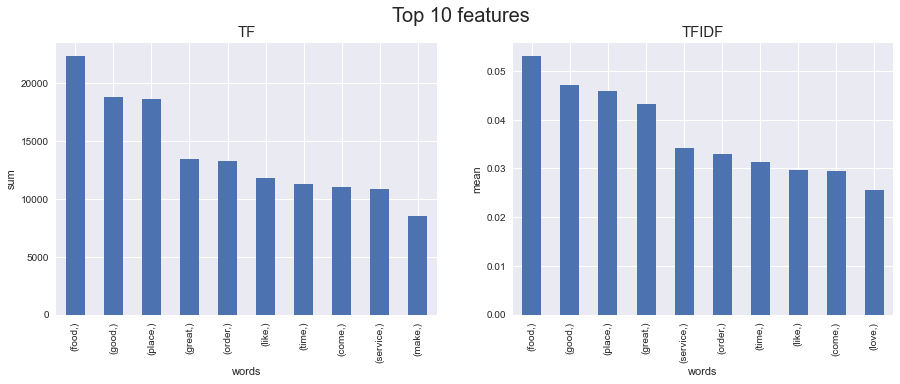

In [336]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.title('TF', size=15)
plt.xlabel('words')
plt.ylabel('sum')
df_features_tf.sum().sort_values(ascending=False).head(10).plot.bar()

plt.subplot(1,2,2)
plt.title('TFIDF', size=15)
plt.xlabel('words')
plt.ylabel('mean')
df_features_tfidf.mean().sort_values(ascending=False).head(10).plot.bar()
plt.suptitle('Top 10 features', size=20)

plt.show()     
    


### NLP Modélisation

#### Sélection du modèle

In [337]:

from matplotlib.legend_handler import HandlerBase
from matplotlib.text import Text


"""
fit lda model
"""
def lda_modelling(n_topics,features):
    
    lda = LatentDirichletAllocation(
        n_components=n_topics, 
        max_iter=5, 
        learning_method='online', 
        learning_offset=50.,
        random_state=0,
        n_jobs=-1
    )

    lda.fit(features.A)
    return lda


"""
plot most representative words weights for each topic of a LDA model
"""
def plot_top_words(model, feature_names, nb_topics, title, n_top_words = 10):

    nb_rows = 1 + (nb_topics//3)
    plt.figure(figsize=(20,nb_rows * 4))
    
    for topic_idx, topic in enumerate(model.components_):
        plt.subplot(nb_rows,3,topic_idx+1)
        plt.title('Topic ' + str(topic_idx+1), size=15)

        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        plt.barh(top_features, weights, height=0.7)
        plt.gca().invert_yaxis()
        plt.xlabel('weights')

        plt.suptitle(title, fontsize=20)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()     
    
    

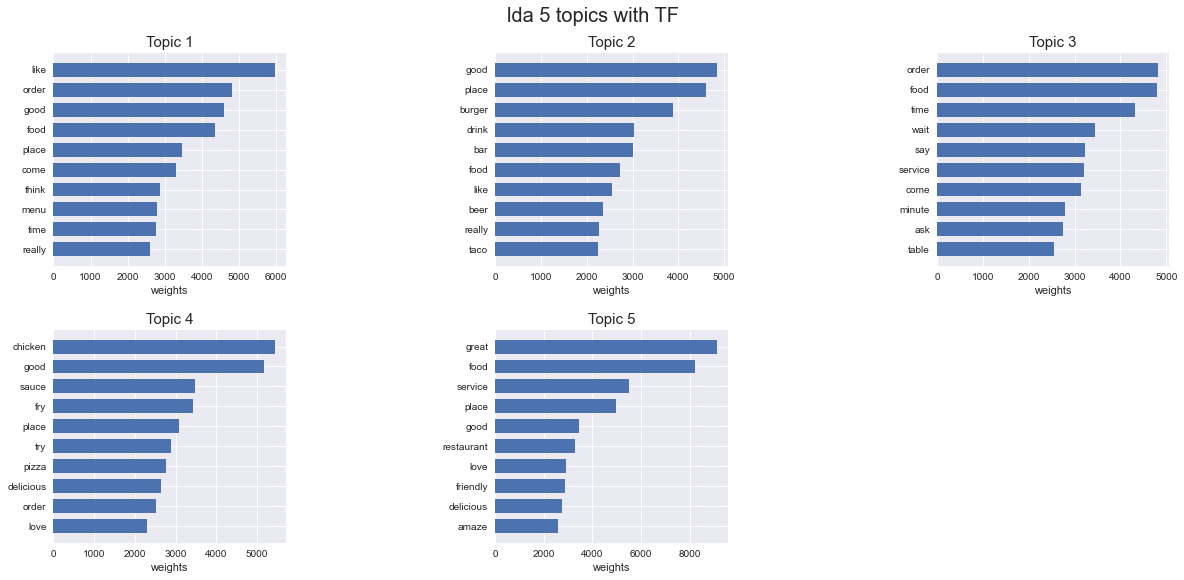

In [338]:
lda_tf_5 = lda_modelling(5,tf_features)
plot_top_words(lda_tf_5, tf_feature_names, 5, 'lda 5 topics with TF')


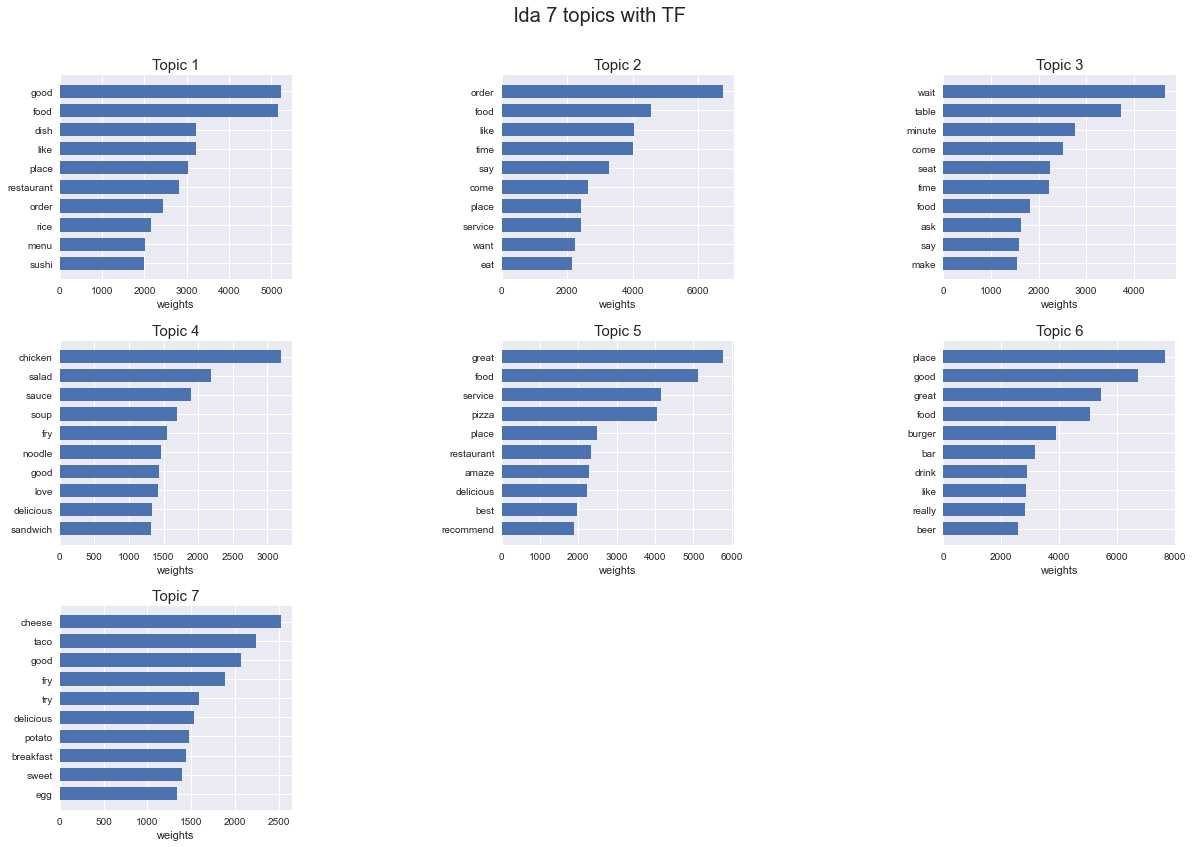

In [339]:
lda_tf_7 = lda_modelling(7,tf_features)
plot_top_words(lda_tf_7, tf_feature_names, 7, 'lda 7 topics with TF')


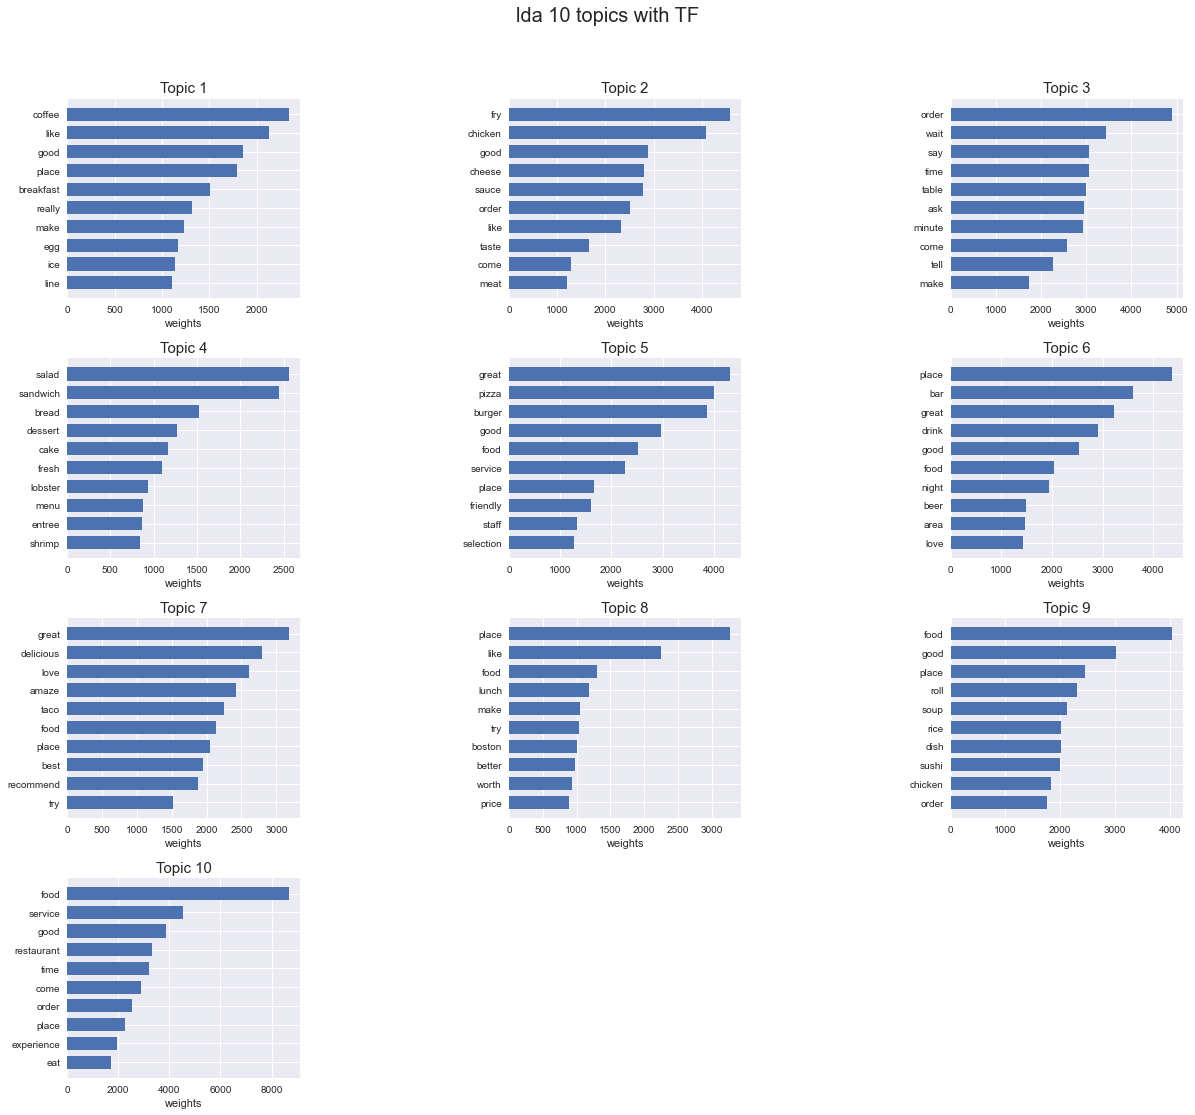

In [340]:
lda_tf_10 = lda_modelling(10,tf_features)
plot_top_words(lda_tf_10, tf_feature_names, 10, 'lda 10 topics with TF')


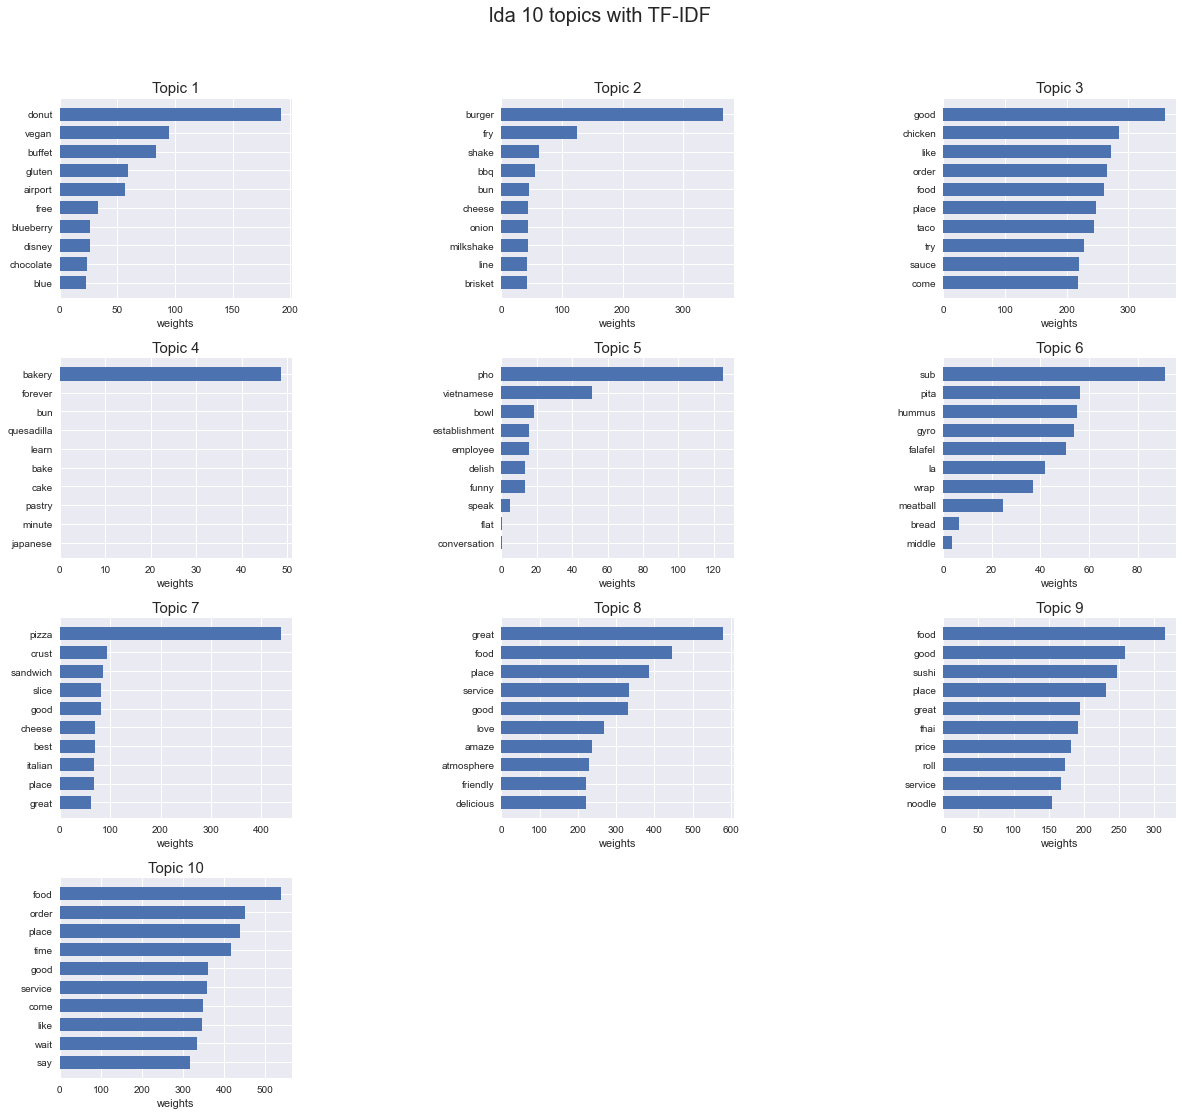

In [341]:
lda_tfidf_10 = lda_modelling(10,tfidf_features)
plot_top_words(lda_tfidf_10, tfidf_feature_names, 10, 'lda 10 topics with TF-IDF')


##### Modèle sélectionné : Term Frequency - 10 topics

In [342]:
best_model = lda_tf_10

### Thèmes

In [343]:

"""
create a dataframe with topics top words
"""
def create_df_topics(lda_model, tf_feature_names, n_top_words = 10):
    df_topics = pd.DataFrame(columns=['topic','top_features'])
    for topic_idx, topic in enumerate(lda_model.components_):
            top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
            top_features = [tf_feature_names[i] for i in top_features_ind]
            df_topics = df_topics.append({
                'topic':topic_idx + 1, 
                'top_features':top_features}, 
                ignore_index=True)
    return df_topics


"""
create a dataframe with lda results for reviews
"""
def create_df_lda_results(lda_results, df_review, df_topics):

    df_results_lda = pd.DataFrame(lda_results)
    df_results_lda = rename_topics_cols(df_results_lda)
    df_results_lda['topic_perc_contrib'] = df_results_lda.max(axis=1)
    df_results_lda['dominant_topic'] = np.argmax(df_results_lda.values, axis=1)+1
    
    df_results_lda = df_review[['review_id','text','stars']].merge(
        df_results_lda,
        left_index=True,
        right_index=True)
    
    df_results_lda = df_results_lda.merge(
        df_topics,right_on='topic',
        left_on='dominant_topic')
    
    df_results_lda = df_results_lda.drop(columns=['topic'])
    
    return df_results_lda


"""
create a dataframe with lda results for topics
"""
def create_df_topics_with_results(df_topics_init, df_lda_results, result_type):

    df_topics = df_topics_init.copy()
    df_topics['result_type'] = result_type
        
    for topic_nb in df_topics['topic']:
        topic_count = len(df_lda_results[df_lda_results['dominant_topic']==topic_nb])    
        df_topics.loc[df_topics['topic'] == topic_nb,['percent']] = (topic_count / df_lda_results.shape[0]) * 100
        
    lda_results_grp = df_lda_results.groupby('dominant_topic')
    df_lda_results_grp = pd.DataFrame()
    
    for i, grp in lda_results_grp:
        df_lda_results_grp = pd.concat(
            [df_lda_results_grp, 
             grp.sort_values(
                 ['topic_perc_contrib'], 
                 ascending=False).head(1)], axis=0)
        
    df_lda_results_grp = df_lda_results_grp.reset_index()[['dominant_topic', 'text', 'topic_perc_contrib']]
    df_lda_results_grp.columns = ['topic', "most representative text", "topic_perc_contrib"]
    
    df_topics = df_topics.merge(df_lda_results_grp, on='topic')

    return df_topics


"""
add 1 to topics numbers
"""
def rename_topics_cols(df):
    for col in df.columns:
        new_col_name = 'topic ' + str(int(col)+1)
        df = df.rename(columns={col: new_col_name})
    return df


"""
plot the word cloud for each topic
"""
def plot_words_clouds(lda, tf_feature_names, nb_topics=10, terms_count = 25):

    nb_rows = 1 + (nb_topics//3)
    plt.figure(figsize=(20,nb_rows * 4))

    for idx,topic in enumerate(lda.components_):

        plt.subplot(nb_rows,3,idx+1)
        plt.title('Topic ' + str(idx+1), size=15)

        abs_topic = abs(topic)
        topic_terms = [[tf_feature_names[i],topic[i]] for i in abs_topic.argsort()[:-terms_count-1:-1]]
        topic_terms_sorted = [[tf_feature_names[i], topic[i]] for i in abs_topic.argsort()[:-terms_count - 1:-1]]
        topic_words = []

        for i in range(terms_count):
            topic_words.append(topic_terms_sorted[i][0])

        dict_word_frequency = {}

        for i in range(terms_count):
            dict_word_frequency[topic_terms_sorted[i][0]] = topic_terms_sorted[i][1]

        wcloud = WordCloud(background_color="white",mask=None, max_words=100,\
        max_font_size=60,min_font_size=10,prefer_horizontal=0.9,
        contour_width=3,contour_color='black')
        wcloud.generate_from_frequencies(dict_word_frequency)
        plt.imshow(wcloud, interpolation='bilinear')
        plt.axis("off")
        
        
"""
print top words for each topic
"""
def print_top_words(model, tf_feature_names, n_top_words = 10):
    for topic_id, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [tf_feature_names[i] for i in top_features_ind]
        print(f'Topic {int(topic_id + 1)} : {top_features}')  



In [344]:
# apply selected model to bag of words
lda_results = best_model.transform(tf_features)

# create the results dataframe
df_topics = create_df_topics(best_model, tf_feature_names)
df_lda_results = create_df_lda_results(lda_results, df_review_sample, df_topics)


##### phrases les plus représentatives

In [345]:
df_topics_all_stars_results = create_df_topics_with_results(df_topics, df_lda_results, result_type = 'all stars')
df_topics_all_stars_results[['topic','most representative text']]

,topic,most representative text
0,1,"Anyone who has a real bagel, a boiled bagel from New York or even Fairfax Ave in LA would throw up in their mouth (just a little bit) to think that Portlanders only have this place at their disposal.\n\nTHESE ARE NOT FRESH BAGELS. THEY ARE REHEATED!! They are just like the stuff you get in the grocery store. Sunrise Bagels has real bagels, but they are under-cooking them so I'll wait for them to get their act together.\n\nMeanwhile, consider Noah's Bagel's the bagel equivalent of a ripoff designer handbag EXCEPT EVERYONE IS BUYING THEM!!!"
1,2,"Seems they stepped it up a bit!\n\nThe ribs I just had here are really good. Tender, falling-off-the-bone, nice sauce. Baked beans (Daddy's Best BBQ Beans) were delish, too. \n\nReeealy tender smoked BBQ HOT wings good potato salad to soothe the burn."
2,3,"Waited for over an hour for a table of 10. Was told by the hostess it would be 40 mins. Watched tons of other patrons, large parties, that came in after us get seated - these people did not have reservations - I know because they gave them those pagers that notifies you when your table is ready. Witnessing whole tables get filled with patrons that arrived after my party, when ours was waiting for over an hour is frustrating. The hostess (the obese woman, with terrible dyed black hair) was so rude when I asked how much longer it would be for a table (this is after waiting for an hour). She refused to provide a time frame for how much longer we would need to wait, kept reminding us that we were walk-in's with a large party as if we didn't know. She then decides to ask us how many children vs. adults there were in the party, and then seats a huge party with no children that came in after my party. The worse part is that the hostess proceeds to talk negatively about us to another empl..."
3,4,"I had the banana bread pudding last night and it was so decedent and delicious!! It was made fresh upon my order, nice warm banana pieces with a nice cream sauce drizzled on top, served in a small cass iron skillet! Perfection!"
4,5,"Definitely best gluten free burger bun that I've ever had. All the sides, with the exception of the onion rings were gluten free as well. This made me extremely happy. Burger was great, but not the best that I've had. Service was super friendly and attentive. Wanted a boozy milkshake but they weren't in the menu..."
5,6,"I pretty much dig the entire concept of this place. An upscale sports bar where you can let your hair down or keep it up, make new friends or socialize exclusively with the ones you came with, have a cocktail or a beer - it fits all molds. It's my favorite bar in the Garden Area and the place I frequent after Blazer Games or when I am forced into that area of town. The food is a little over priced, but the staff is friendly. There's an upstairs part with a lot of tables and easy chairs at the entrances, cool signs and sports memorabilia. Downstairs the music gets louder and the space opens if you feel like getting your groove on. It does the trick and it does it well."
6,7,"We had the chef tasting menu with wine pairing and we were blown away! Everything was perfect. The dishes were innovative and perfectly executed. Best food we had in Austin in years. Service was great and super friendly. Thank you Nitza, Stefan and all the chefs for an amazing night."
7,8,"Be careful, this place pretends to be ""Austin"" and instead turns into Dave & Busters (on a bad day). \nNobody there from Austin\nNobody there has a soul\nAnd the entire place smells like urine"
8,9,"I ate here today for lunch and for Pho it is pretty good. I did not get the traditional beef pho, instead I opted for the chicken pho. I wish the broth was a little bit more complex in flavor, but the noodles were cooked perfectly and there was a generous portion of chicken in the dish. I also had the quail as an appetizer. It was crispy and had a very good flavor to it. The mixed vegetable salad with it was a gre

##### Nuage de mots

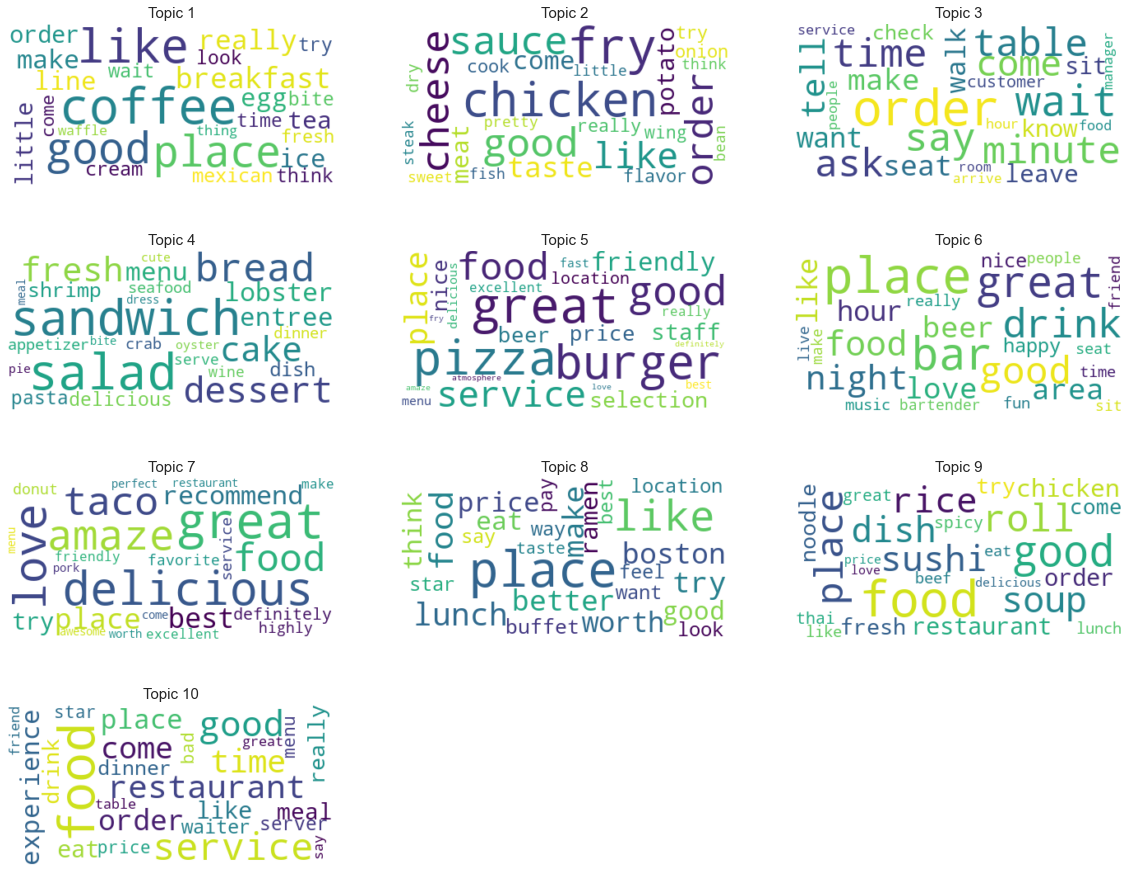

In [346]:
plot_words_clouds(best_model,tf_feature_names,nb_topics=10,terms_count = 25)


##### liste des 10 mots les plus représentatifs par topic

In [347]:
print_top_words(best_model, tf_feature_names, n_top_words = 10)


Topic 1 : ['coffee', 'like', 'good', 'place', 'breakfast', 'really', 'make', 'egg', 'ice', 'line']
Topic 2 : ['fry', 'chicken', 'good', 'cheese', 'sauce', 'order', 'like', 'taste', 'come', 'meat']
Topic 3 : ['order', 'wait', 'say', 'time', 'table', 'ask', 'minute', 'come', 'tell', 'make']
Topic 4 : ['salad', 'sandwich', 'bread', 'dessert', 'cake', 'fresh', 'lobster', 'menu', 'entree', 'shrimp']
Topic 5 : ['great', 'pizza', 'burger', 'good', 'food', 'service', 'place', 'friendly', 'staff', 'selection']
Topic 6 : ['place', 'bar', 'great', 'drink', 'good', 'food', 'night', 'beer', 'area', 'love']
Topic 7 : ['great', 'delicious', 'love', 'amaze', 'taco', 'food', 'place', 'best', 'recommend', 'try']
Topic 8 : ['place', 'like', 'food', 'lunch', 'make', 'try', 'boston', 'better', 'worth', 'price']
Topic 9 : ['food', 'good', 'place', 'roll', 'soup', 'rice', 'dish', 'sushi', 'chicken', 'order']
Topic 10 : ['food', 'service', 'good', 'restaurant', 'time', 'come', 'order', 'place', 'experience', 

##### Labelisation des topics

In [348]:
topics_labels = {
    '1' : 'petit déjeuner',
    '2' : 'repas classique',
    '3' : 'attente',
    '4' : 'repas froid',
    '5' : 'fast food',
    '6' : 'bar',
    '7' : 'satisfaction',
    '8' : 'lieu',
    '9' : 'asiatique',
    '10' : 'service'
}


'1' : 'petit déjeuner'  
'2' : 'repas classique'  
'3' : 'attente'  
'4' : 'repas froid'  
'5' : 'fast food'  
'6' : 'bar'  
'7' : 'satisfaction'  
'8' : 'lieu'  
'9' : 'asiatique'  
'10' : 'service'  


### NLP - Visualisation des résultats

#### pyLDAvis

In [349]:
import pyLDAvis.sklearn
pyLDAvis.enable_notebook()


In [350]:
pyLDAvis.sklearn.prepare(
    best_model, 
    tf_features, 
    tf_vectorizer)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.223709  0.009425       1        1  15.174983
9      0.058422 -0.033753       2        1  13.337518
8     -0.080107  0.040646       3        1  12.145478
5      0.017942 -0.153517       4        1  10.612111
1      0.008032  0.169720       5        1  10.528405
6     -0.168856 -0.082735       6        1   9.701862
0      0.114839  0.049280       7        1   8.939861
7      0.163901 -0.008129       8        1   6.974529
4     -0.142700 -0.228992       9        1   6.393366
3     -0.195180  0.238055      10        1   6.191887, topic_info=          Term          Freq         Total Category  logprob  loglift
383      great  13234.000000  13234.000000  Default  30.0000  30.0000
657      pizza   4028.000000   4028.000000  Default  29.0000  29.0000
119     burger   3844.000000   3844.000000  Default  28.0000  28.0000
358        fry   5201.000000   5201.000000  Default  27.0000  27.0000
152    chicken   5924.000000   5924.000000  Default  26.0000  26.0000
..         ...           ...           ...      ...      ...      ...
782      serve    623.016493   3100.429352  Topic10  -4.6213   1.1772
159  chocolate    444.061841   1100.537539  Topic10  -4.9599   1.8743
84        bite    505.157904   4073.114644  Topic10  -4.8310   0.6946
532       meal    501.326123   3948.670510  Topic10  -4.8386   0.7181
610      order    474.288847  13176.992891  Topic10  -4.8941  -0.5425

[599 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
1         1  0.033646  absolutely
1         2  0.146733  absolutely
1         3  0.062619  absolutely
1         4  0.046730  absolutely
1         5  0.017757  absolutely
...     ...       ...         ...
993       9  0.016969        year
993      10  0.008485        year
994       3  0.889484      yellow
994       7  0.058971      yellow
994      10  0.049143      yellow

[1807 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 10, 9, 6, 2, 7, 1, 8, 5, 4])

#### Distribution des reviews par topic

In [351]:

"""
plot the number of reviews by topic
"""
def plot_results(plot_type, df_results, topics_labels_legend = None, loc = 'upper left'):
    
    if plot_type == 'count':
        df_results_temp = df_results.copy()
        df_results_temp = df_results_temp.rename(columns={
            'dominant_topic':'topic'
        })
        ax = sns.countplot(df_results_temp['topic'])
    elif plot_type == 'percent':
        ax = sns.barplot(data=df_results,x='topic',y='percent', hue='result_type',palette=['blue','red'],alpha=.5,)
        hue_legend = ax.get_legend()
        
    if topics_labels_legend is not None:
        add_legend(ax, topics_labels_legend, loc)
        if plot_type == 'percent':
            ax.add_artist(hue_legend)

            
"""
add a legend to the plot
"""    
def add_legend(ax, topics_labels,loc):
    
    topics_keys = topics_labels.keys()
    topics_labels = topics_labels.values()
    
    class TextHandler(HandlerBase):
        def create_artists(self, legend, tup ,xdescent, ydescent,
                        width, height, fontsize,trans):
            tx = Text(width/2.,height/2,tup[0], fontsize=fontsize,
                  ha="center", va="center", color=tup[1], fontweight="bold")
            return [tx]

    t = ax.get_xticklabels()
    labeldic = dict(zip(topics_keys, topics_labels))
    labels = [labeldic[h.get_text()]  for h in t]
    handles = [(h.get_text(),c.get_fc()) for h,c in zip(t,ax.patches)]
    
    if (loc == 'out'):
        ax.legend(handles, labels, handler_map={tuple : TextHandler()}, loc='center left', bbox_to_anchor=(1, 0.5)) 
    else:
        ax.legend(handles, labels, handler_map={tuple : TextHandler()}, loc=loc) 
    
    return ax



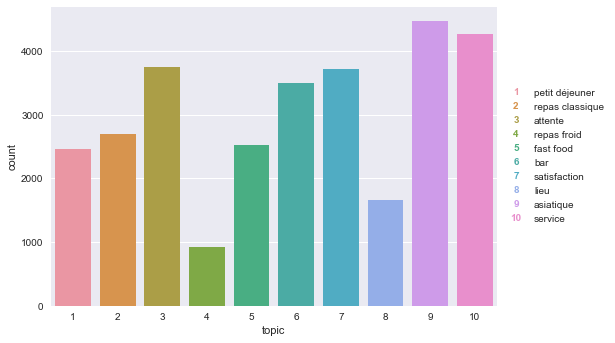

In [352]:
plot_results('count', df_lda_results,topics_labels, 'out')


In [353]:

"""
define a pipeline with a preprocessor, a vectorizer and a model
"""
def define_pipeline(preprocessor_text, vectorizer, model):
    pipe = Pipeline([('preprocessor',preprocessor_text), ('vectorize', vectorizer), ('model', model)] )
    return pipe

In [354]:

# pipeline final
pipe_topic_modeling = define_pipeline(preprocessor_text_pipe, tf_vectorizer, best_model)


### Prédictions

In [355]:
"""
apply final topic modeling pipeline to a text
get the dominant topic
get the topic label
returns predicted topic number and label
"""
def predict(text):
    lda_results_my_test = pipe_topic_modeling.transform(text)
    topic_predict_nb = np.argmax(lda_results_my_test) + 1
    topic_predict_label = topics_labels[str(topic_predict_nb)]
    return topic_predict_nb, topic_predict_label

In [356]:
my_test = 'I took my breakfast in this restaurant. I love drink coffee end the eggs were delicious.'
topic_predict_nb, topic_predict_label = predict(my_test)
print('Custom test:')
print(my_test)
print(f'Prédiction : Topic {topic_predict_nb} - {topic_predict_label}')

Custom test:
I took my breakfast in this restaurant. I love drink coffee end the eggs were delicious.
Prédiction : Topic 1 - petit déjeuner


### Sujets d'insatisfaction


In [357]:
# bad reviews
bad_reviews_stars = [1.0,2.0]
df_review_bad_stars = df_review_business_restau[df_review_business_restau['stars'].isin(bad_reviews_stars)].reset_index()

# apply topic modeling pipeline to bad reviews
lda_results_bad_stars = pipe_topic_modeling.transform(df_review_bad_stars['text'])


In [358]:
# results by reviews
df_lda_results_bad_stars = create_df_lda_results(lda_results_bad_stars, df_review_bad_stars, df_topics)

# results by topic
df_topics_bad_stars_result = create_df_topics_with_results(df_topics, df_lda_results_bad_stars, result_type = 'bad stars')

# concatene results by topic for all stars and bad stars
df_topics_compare = pd.concat([df_topics_all_stars_results, df_topics_bad_stars_result])    


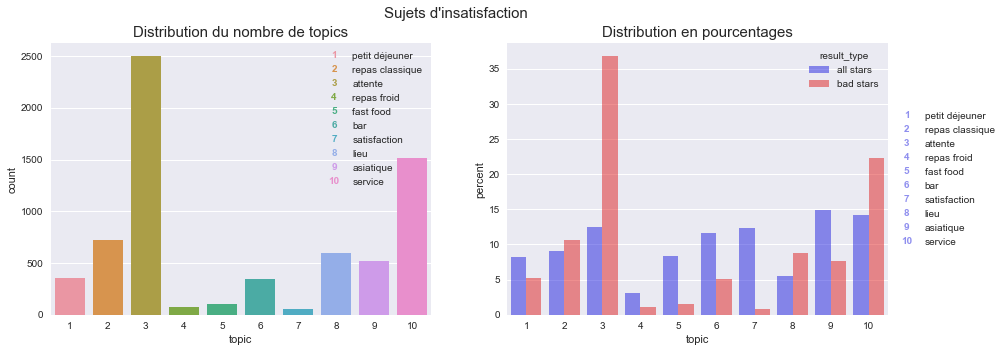

In [359]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.title('Distribution du nombre de topics', size=15)
plot_results('count', df_lda_results_bad_stars, topics_labels, 'upper right')

plt.subplot(1,2,2)
plt.title('Distribution en pourcentages', size=15)
plot_results('percent', df_topics_compare, topics_labels, 'out')

plt.suptitle('Sujets d\'insatisfaction', size=15)
plt.show()    

## ***** Collecte de données via l'API Yelp *****

In [360]:
from gql import gql,Client
from gql.transport.requests import RequestsHTTPTransport
from dotenv import load_dotenv
import os


"""
define yelp gql client
"""
def define_yelp_gql_client():

    load_dotenv()
    
    api_key = os.environ.get("YELP_API_KEY")

    header = {'Authorization' : 'bearer {}'.format(api_key),
             'Content-Type' : 'application/json'}

    yelp_url = 'https://api.yelp.com/v3/graphql'

    transport = RequestsHTTPTransport(url = yelp_url, headers = header, use_json = True)
    client = Client(transport = transport, fetch_schema_from_transport = True)

    return client


"""
get businesses with gql for a given location
"""
def set_yelp_business_gql_query(location, offset, limit):
    query = '''
    {
      search(categories:"restaurant",
             location:"%s",
            limit:%d,
            offset:%d) {
        business {
          id
          name
          reviews {
            id
            text
            rating
          }
        }
      }
    }
    ''' %(location, limit, offset)
    gql_query = gql(query)
    return gql_query


"""
get yelp businesses for a location list and businesses count
"""
def get_yelp_business(locations, business_count):

    df_reviews_collect = pd.DataFrame()

    location_count = calc_location_count(locations)
    current_sum_req = 0
    business_rest = business_count
    
    while business_rest > 0 :

        offset, current_sum_req, location_rest, business_rest = calc_offset(business_count, current_sum_req, location_count)
        location_search = 0

        for location in locations: 

            location_search +=1
            if location_search > location_rest:
                break

            gql_query = set_yelp_business_gql_query(location,offset,offset)

            try:
                response = yelp_gql_client.execute(gql_query)
            except Exception as e:
                print(e)
                break

            for business in response['search']['business']:
                df_reviews_collect = add_business_to_df(business,df_reviews_collect,location)

    df_reviews_collect = df_reviews_collect_format(df_reviews_collect)
    
    return df_reviews_collect


"""
returns the locations count
"""
def calc_location_count(locations):
    return len(locations)
    
    
"""
calc the offset according to business_count, current_sum_req, location_count
"""    
def calc_offset(business_count, current_sum_req, location_count):
   
    rest = business_count - current_sum_req
    offset = rest // location_count
    
    if offset == 0:
        i = 0
        while offset == 0:
            i+=1
            offset = rest // (location_count-i)
        location_rest = offset * (location_count-i)
    else:
        location_rest = location_count 
    
    if offset > 50:
        offset = 50
        
    current_sum_req = current_sum_req + (offset * location_rest)
    business_rest = business_count - current_sum_req
        
    return offset, current_sum_req, location_rest, business_rest    
    

"""
add the collected business reviews to the reviews dataframe
"""    
def add_business_to_df(business,df_reviews_collect,location):
    df_review = pd.json_normalize(business['reviews'])
    df_review['business_id'] = business['id']
    df_review['business_name'] = business['name']
    df_review['city'] = location
    df_reviews_collect = pd.concat([df_reviews_collect, df_review])    
    return df_reviews_collect


"""
format the reviews collect dataframe
"""
def df_reviews_collect_format(df_reviews_collect):
    
    # compatibilty names
    df_reviews_collect = df_reviews_collect.rename(columns={
        'id':'review_id',
        'rating':'stars',
    })
    
    # columns order
    df_reviews_collect = df_reviews_collect[['business_id', 'business_name', 'city', 'review_id', 'stars', 'text']]        
    
    df_reviews_collect = df_reviews_collect.sort_values(by=['city'])
    df_reviews_collect = df_reviews_collect.reset_index(drop=True)
    
    return df_reviews_collect


"""
create a dataframe with business count and review count by cities
"""      
def business_review_count(df_reviews_collect):
    df_reviews_collect_stats = df_reviews_collect.groupby(['city']).agg({
        'business_id': 'nunique', 
        'review_id': lambda x: len(x)
    }).rename(columns={
        'business_id':'business count',
        'review_id':'review count',
    }).reset_index()
    return df_reviews_collect_stats
    

#### Synthèse de la collecte

In [361]:
yelp_gql_client = define_yelp_gql_client()

business_count = 200
locations = ['Chicago','Paris','Los Angeles', 'Rome']

df_reviews_collect = get_yelp_business(locations,business_count)


In [362]:
business_review_count(df_reviews_collect)


,city,business count,review count
0,Chicago,50,150
1,Los Angeles,50,150
2,Paris,50,150
3,Rome,50,150


#### Extrait des données collectées


In [363]:
df_reviews_collect

,business_id,business_name,city,review_id,stars,text
0,PZe0q_153VHUnaR-8dOTJg,The Dearborn,Chicago,zNRp49X5JUhN6M7efCLzkg,5,"I am a very picky eater and was in Chicago on a business trip. I called ahead to the restaurant to ask some questions about their menu. I spoke with Greg,..."
1,mCHto10PBQOKnefm7gholg,90 Miles Cuban Café,Chicago,5KVRC8OCu0uC-SBqXIAwfQ,5,Amazing food. Amazing service. Amazing decor. What's not to love? This is my favorite go-to for Cuban.
2,mCHto10PBQOKnefm7gholg,90 Miles Cuban Café,Chicago,VVwJR2s3PFGFcehIn8wAqQ,5,"THE BEST! AMAZING empanadas, amazing cubano, amazing coffee, the list goes on. I have been coming here for ages and it's perfect everytime. Great lively..."
3,mCHto10PBQOKnefm7gholg,90 Miles Cuban Café,Chicago,VA-M-LaW_Vxr_855lJD4NA,5,The food is absolutely amazing and such friendly staff! Their empanadas delicious! Highly recommend!
4,uyUKtGWLYgu-RLjlNImy0A,Tango Sur,Chicago,rE9DSp1wOzgjFgAKPrNI4Q,5,We love this place and always come here when in Chicago.\nThis time we tried several starters. The empanadas were amazing - crispy and stuffed with different...
...,...,...,...,...,...,...
595,npxRjMtNY8t5BRD3WGMwgQ,Sette Oche,Rome,mNJGuGaMKQrJjmop86DVnA,5,I ended up coming here twice on my last visit to Rome.... I was a bit worried as it wasn't empty but just there wasn't a line and had some open tables which...
596,9O-MvxV1Cr1DZxfnqly56Q,Cacio e Pepe,Rome,FuTB0BWCXFJyMWxXlayL2Q,5,Authentic Roman cuisine. Good prices and a very casual atmosphere. Try the carbonara or cacio e Pepe
597,9O-MvxV1Cr1DZxfnqly56Q,Cacio e Pepe,Rome,lSdDbvJ-gf9sQGXLB2BQ4A,3,Stopped in here for lunch in Rome. I ordered the Cacio e Pepe (half portion) and the Carbonara (half portion) so I could try and taste more things on the...
598,v_hRfyB1cttzb5Y6vKe7Iw,Pastasciutta,Rome,DdMrD2zC1EqjzBam9erPbg,5,"Italy and Rome in particular obviously have amazing pasta restaurants on practically every corner, but Pastascuitta stands out. This shop, steps away from..."


#### Utilisation de l'API Yelp 


In [364]:
import ipywidgets as widgets
from ipywidgets import interact, interact_manual, FloatSlider, IntSlider
from ipywidgets import Button, HBox, VBox, Layout
from IPython.display import display, clear_output


output = widgets.Output()

locations_list = ['Paris', 'Berlin', 'Rome', 'Londres', 'Chicago'] + df_business['city'].unique().tolist()
locations_list_selected = []

df_reviews_collect_interact = pd.DataFrame()

select1 = widgets.SelectMultiple(
    options=locations_list,
    value=['Paris'],
    layout={'width': '200px'}
)

select2 = widgets.Select(
    options=locations_list_selected,
    layout={'width': '200px'}
)

button_add = widgets.Button(
    description = 'Add ->', 
    layout={'width': '100px'}
)

button_clear = widgets.Button(
    description = 'clear',
    layout={'width': '100px'}
)

button_yelp = widgets.Button(
    description = 'yelp business',
     button_style = 'success'
)

button_topic = widgets.Button(
    description = 'topics',
     button_style = 'success'
)

business_count_text = widgets.IntText(
    value=2,
    layout={'width': '50px'}
)

label_cities = widgets.Label()
label_select_cities = widgets.Label()
label_business_count = widgets.Label()
label_messages = widgets.Label()

label_cities.value = 'Cities'
label_select_cities.value = 'Selected Cities'
label_business_count.value = 'business count'

def update_selected_cities(_):
    new_list=[]
    for option in select2.options:
        new_list.append(option)
    for value in select1.value:
        if value not in new_list:
            new_list.append(value)
    select2.options = new_list

def clear_selected_cities(_):
    select2.options = []

def display_output():
    display_(widgets.VBox([hbox3, hbox2, button_yelp]))
    
def yelp_business(_):
    output.clear_output()
    display_output()

    no_error = True
    
    if business_count_text.value > 20:
        display_('max business count 20 for demo')
        label_messages.value = 'max business count 20 for demo'
        no_error = False
    
    if business_count_text.value <= 0:
        display_('business count must be greater than 0')
        label_messages.value = 'business count must be greater than 0'
        no_error = False

    if not(select2.value):
        display_('no city selected')
        label_messages.value = 'no city selected'
        no_error = False
    
    if no_error:
        global df_reviews_collect_interact
        df_reviews_collect_interact = get_yelp_business(select2.options,business_count_text.value)
        display_(df_reviews_collect_interact)

def display_(to_display):
     with output:
        display(to_display)
    
button_add.on_click(update_selected_cities)
button_clear.on_click(clear_selected_cities)

hbox1 = widgets.HBox([label_select_cities , button_clear])
hbox2 = widgets.HBox([label_business_count , business_count_text], layout = Layout( margin = ' 20px 0 20px 0 ' ))

vbox1 = widgets.VBox([label_cities, select1])
vbox2 = widgets.VBox([button_add], layout = Layout( margin = ' 60px 0 0 0 ' ))
vbox3 = widgets.VBox([hbox1, select2])

hbox3 = widgets.HBox([vbox1 , vbox2, vbox3])

button_yelp.on_click(yelp_business)

display_output()
output

    


Output()

## ***** Labellisation des photos *****

In [365]:
yelp_photos_path = data_path + "yelp_photos/"
photos_path = yelp_photos_path + "photos/"


In [366]:
df_photos = pd.read_json(yelp_photos_path + 'photos.json',lines=True)


#### Aperçu des catégories

In [367]:
df_photos.groupby("label").count()[['photo_id']]

,photo_id
label,
drink,40000
food,40000
interior,40000
menu,40000
outside,40000


In [368]:

"""
returns the photo id for a label at a position in the list
"""
def get_photo(label,pos):
    return [list_photos[i] for i in range(len(df_photos)) if df_photos["label"][i]==label][pos]

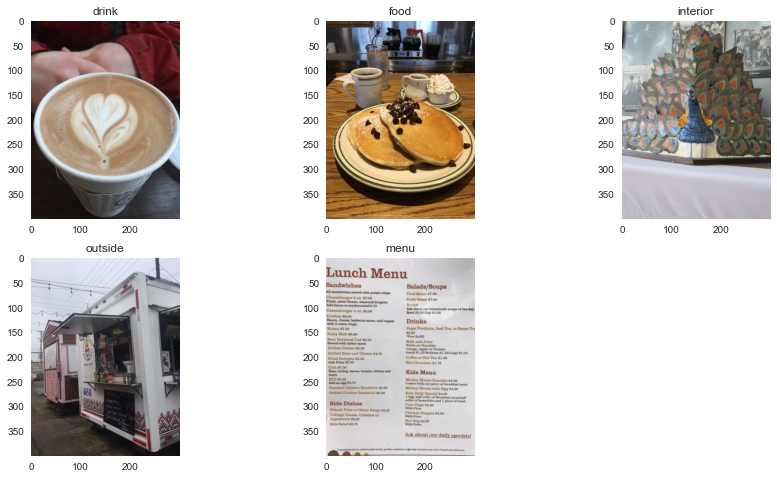

In [369]:
from matplotlib.image import imread

list_photos = df_photos['photo_id']
list_labels = df_photos['label'].unique()

plt_pos = 1
photo_pos = 5
plt.figure(figsize=(15,8))

for label in list_labels :
    photo_name = get_photo(label, photo_pos)
    filename = photos_path + photo_name + '.jpg'
    plt.subplot(230 + plt_pos)
    plt.title(label)
    image = imread(filename)
    plt.grid(False)
    plt.imshow(image)
    plt_pos+=1

#### Pré-traitement et détection des descripteurs pour une photo


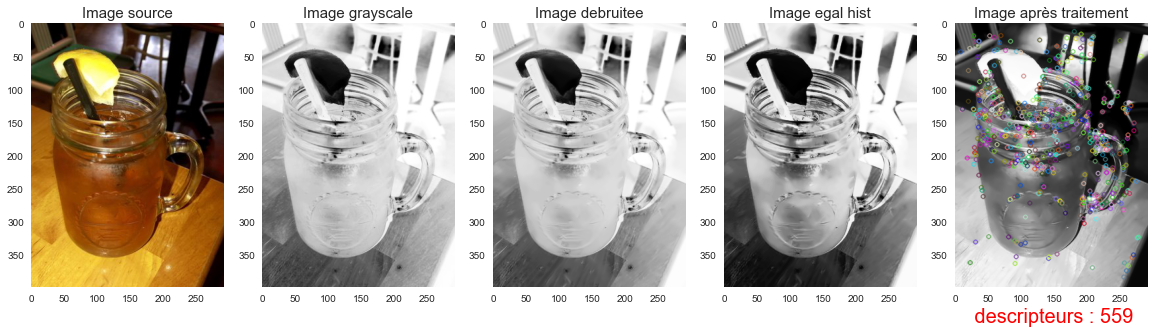

In [370]:
import cv2

filename = photos_path + list_photos[1000] + '.jpg'

image_src = imread(filename)

img_gray = cv2.imread(filename,0) # convert in gray
img_denois = cv2.fastNlMeansDenoising(img_gray, None, 3, 7, 21); # remove noise
img_equalhist = cv2.equalizeHist(img_denois)   # equalize image histogram

# sift keypoints detection
sift = cv2.xfeatures2d.SIFT_create()
kp, des = sift.detectAndCompute(img_equalhist, None)
img = cv2.drawKeypoints(img_equalhist,kp,img_equalhist)

plt.figure(figsize=(20,10))

plt.subplot(1,5,1)
plt.title('Image source', size=15)
plt.grid(False)
plt.imshow(image_src)

plt.subplot(1,5,2)
plt.title('Image grayscale', size=15)
plt.grid(False)
plt.imshow(img_gray)

plt.subplot(1,5,3)
plt.title('Image debruitee', size=15)
plt.grid(False)
plt.imshow(img_denois)

plt.subplot(1,5,4)
plt.title('Image egal hist', size=15)
plt.grid(False)
plt.imshow(img_equalhist)

plt.subplot(1,5,5)
plt.title('Image après traitement', size=15)
plt.xlabel(' descripteurs : ' + str(des.shape[0]), size=20, color='red')
plt.grid(False)
plt.imshow(img)

plt.show()     



### Création des 'bags of visual words'


In [371]:
"""
preprocess the photo
"""
def photo_preprocess(filename):
    img_gray = cv2.imread(filename,0) # convert in gray
    img_denois = cv2.fastNlMeansDenoising(img_gray, None, 3, 7, 21); # remove noise
    img_equalhist = cv2.equalizeHist(img_denois)   # equalize image histogram
    return img_equalhist 

In [372]:
sample_size = 500

df_photos_drink = df_photos[df_photos['label']=='drink']
df_photos_food = df_photos[df_photos['label']=='food']
df_photos_interior = df_photos[df_photos['label']=='interior']
df_photos_menu = df_photos[df_photos['label']=='menu']
df_photos_outside = df_photos[df_photos['label']=='outside']

# df_photos_sample = pd.concat(
#     [df_photos_drink.sample(sample_size),
#      df_photos_food.sample(sample_size),
#      df_photos_interior.sample(sample_size),
#      df_photos_menu.sample(sample_size),
#      df_photos_outside.sample(sample_size)]).reset_index()
df_photos_sample = pd.read_csv(data_path + 'df_photos_sample.csv')

list_photos_sample = df_photos_sample['photo_id']
list_labels = df_photos_sample['label'].unique()


In [373]:
import time, cv2

sift_keypoints = []
sift = cv2.xfeatures2d.SIFT_create(500)

# identification of key points and associated descriptors
for image_num in range(len(list_photos_sample)):
    
    filename = photos_path + list_photos_sample[image_num] + '.jpg'

    img_preprocess = photo_preprocess(filename)

    sift = cv2.xfeatures2d.SIFT_create()
    kp, des = sift.detectAndCompute(img_preprocess, None)
    sift_keypoints.append(des)

sift_keypoints_by_img = np.asarray(sift_keypoints)
sift_keypoints_all    = np.concatenate(sift_keypoints_by_img, axis=0)

print("Nombre de descripteurs : ", sift_keypoints_all.shape[0])


Nombre de descripteurs :  2799441


In [374]:
from sklearn import cluster, metrics

# estimated number of clusters
k = int(round(np.sqrt(len(sift_keypoints_all)),0))

# Clustering
kmeans = cluster.MiniBatchKMeans(n_clusters=k, init_size=3*k, random_state=0)
kmeans.fit(sift_keypoints_all)

MiniBatchKMeans(init_size=5019, n_clusters=1673, random_state=0)

In [375]:

"""
faetures histogram creation for an image
"""
def build_histogram(kmeans, des, image_num):
    
    # affect each descriptor to a cluster
    res = kmeans.predict(des)
    
    # init histogram to the cluster numbers size
    hist = np.zeros(len(kmeans.cluster_centers_))
    
    # descriptors number ponderation by cluster
    nb_des=len(des)
    if nb_des==0: 
        print("nombre des descripteurs à 0, image  : ", image_num)
        return hist
    
    # histiogram increment dof each cluster
    for i in res:
        hist[i] += 1.0/nb_des
    return hist

In [376]:



hist_vectors=[]

# Creation of a matrix of histograms
for i, image_desc in enumerate(sift_keypoints_by_img) :
    hist = build_histogram(kmeans, image_desc, i) #calculates the histogram
    hist_vectors.append(hist) #histogram is the feature vector

im_features = np.asarray(hist_vectors)



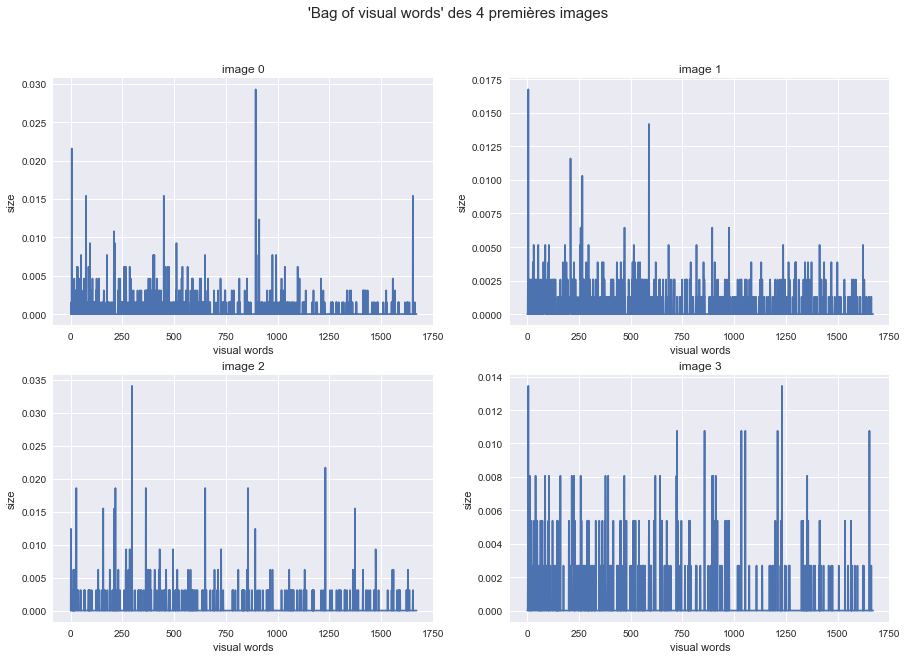

In [377]:
plt.figure(figsize=(15,10))
plt.suptitle("'Bag of visual words' des 4 premières images",size=15)
for i in range(4):
    plt.subplot(220 + 1 + i)
    plt.title('image '+str(i))
    plt.xlabel('visual words')
    plt.ylabel('size')
    df_im = pd.DataFrame(im_features[i])
    plt.plot(df_im)


In [378]:
from sklearn import manifold, decomposition

pca = decomposition.PCA(n_components=0.99)
feat_pca = pca.fit_transform(im_features)


In [379]:
from sklearn import manifold, decomposition
from sklearn import preprocessing

tsne = manifold.TSNE(n_components=2, perplexity=30, 
                     n_iter=2000, init='random', random_state=6)
X_tsne = tsne.fit_transform(feat_pca)


In [380]:
from sklearn import cluster, metrics

cls = cluster.KMeans(n_clusters=5, random_state=6)
cls.fit(X_tsne)


KMeans(n_clusters=5, random_state=6)

### Visualisation selon les clusters et les vraies classes


In [381]:
df_tsne = pd.DataFrame(X_tsne[:,0:2], columns=['tsne1', 'tsne2'])

df_tsne["cluster"] = cls.labels_
df_tsne["true_label"] = df_photos_sample["label"]

In [382]:
le = preprocessing.LabelEncoder()
df_tsne["true_label_code"] = le.fit_transform(df_tsne["true_label"])

In [383]:
conf_mat = metrics.confusion_matrix(df_tsne["true_label_code"], df_tsne["cluster"])


In [384]:
# conf_mat

In [385]:
# np.argmax(conf_mat, axis=0)

In [386]:
corresp = [3, 0, 4, 1, 2]
# corresp = np.argmax(conf_mat, axis=0)
df_tsne['cluster_corresp'] = df_tsne['cluster'].apply(lambda x : corresp[x]) 

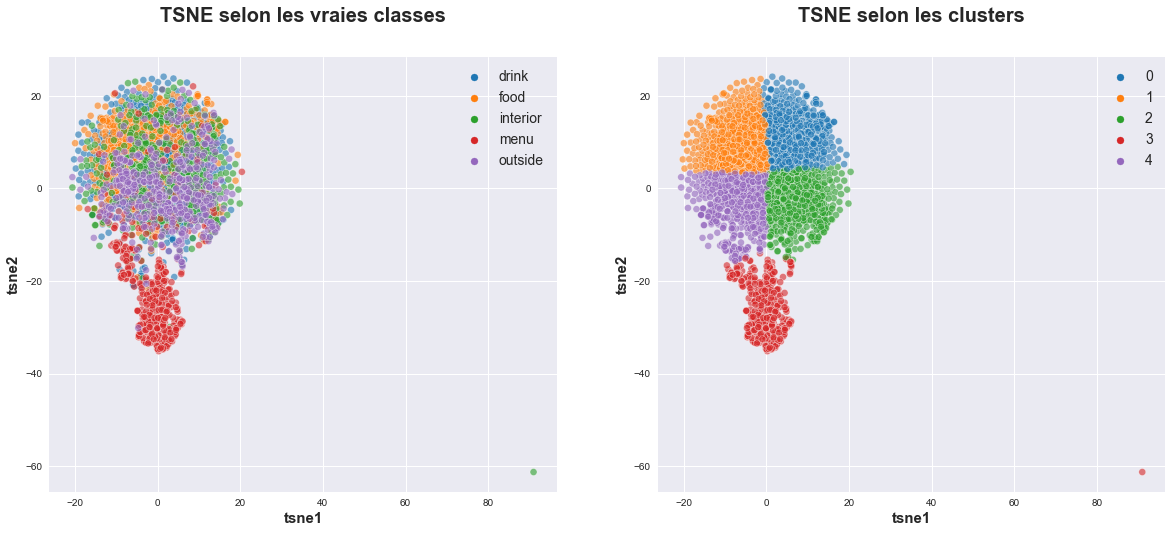

In [387]:

# true labels
plt.figure(figsize=(20,8))
plt.subplot(1,2,1)
sns.scatterplot(
    x="tsne1", y="tsne2", 
    hue="true_label", 
    palette=sns.color_palette('tab10', n_colors=5), s=50, alpha=0.6,
    data=df_tsne, 
    legend="brief")
plt.title('TSNE selon les vraies classes', fontsize = 20, pad = 35, fontweight = 'bold')
plt.xlabel('tsne1', fontsize = 15, fontweight = 'bold')
plt.ylabel('tsne2', fontsize = 15, fontweight = 'bold')
plt.legend(prop={'size': 14}) 

# clusters
plt.subplot(1,2,2)
sns.scatterplot(
    x="tsne1", y="tsne2",
    hue="cluster_corresp",
    palette=sns.color_palette('tab10', n_colors=5), s=50, alpha=0.6,
    data=df_tsne,
    legend="brief")
plt.title('TSNE selon les clusters', fontsize = 20, pad = 35, fontweight = 'bold')
plt.xlabel('tsne1', fontsize = 15, fontweight = 'bold')
plt.ylabel('tsne2', fontsize = 15, fontweight = 'bold')
plt.legend(prop={'size': 14}) 

plt.show()    





### Evaluation


##### ARI score

In [388]:
ari_score = metrics.adjusted_rand_score(df_tsne["true_label_code"], df_tsne["cluster_corresp"])

In [389]:
ari_score

0.1995625008596323

##### matrice de confusion

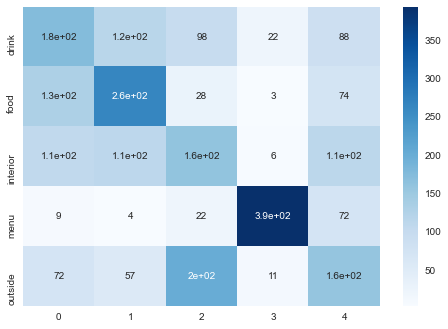

In [390]:
conf_mat_corresp = metrics.confusion_matrix(df_tsne["true_label_code"], df_tsne["cluster_corresp"])

df_cm = pd.DataFrame(conf_mat_corresp, index = [label for label in list_labels])

sns.heatmap(df_cm, annot=True, cmap="Blues")
plt.show()

##### classification report

In [391]:
print(metrics.classification_report(df_tsne["true_label_code"], df_tsne["cluster_corresp"]))

              precision    recall  f1-score   support

           0       0.35      0.35      0.35       500
           1       0.48      0.53      0.50       500
           2       0.32      0.32      0.32       500
           3       0.90      0.79      0.84       500
           4       0.31      0.32      0.31       500

    accuracy                           0.46      2500
   macro avg       0.47      0.46      0.47      2500
weighted avg       0.47      0.46      0.47      2500

